In [91]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer 
from sklearn.decomposition import PCA
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visuals
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

In [92]:
# Reading the data

data = pd.read_csv('../data/preprocessed/marketing_campaign_preprocessed.csv')

print(data.info())
data.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 2229 entries, 0 to 2228
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        2229 non-null   int64  
 1   Education                 2229 non-null   str    
 2   Income                    2229 non-null   float64
 3   Recency                   2229 non-null   int64  
 4   MntWines                  2229 non-null   float64
 5   MntFruits                 2229 non-null   float64
 6   MntMeatProducts           2229 non-null   float64
 7   MntFishProducts           2229 non-null   float64
 8   MntSweetProducts          2229 non-null   float64
 9   MntGoldProds              2229 non-null   float64
 10  NumDealsPurchases         2229 non-null   int64  
 11  NumWebPurchases           2229 non-null   int64  
 12  NumCatalogPurchases       2229 non-null   int64  
 13  NumStorePurchases         2229 non-null   int64  
 14  NumWebVisitsMonth  

,ID,Education,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Purchases,Total_Accepted_Campaigns,Children_at_home,Living_With,Family_Size
0,5524,Graduate,58138.0,58,6.455199,4.488636,6.304449,5.153292,4.488636,4.488636,...,0,1,69,4928,31.378848,25,0,0,Alone,1
1,2174,Graduate,46344.0,38,2.484907,0.693147,1.945910,1.098612,0.693147,1.945910,...,0,0,72,4378,8.861634,6,0,2,Alone,3
2,4141,Graduate,71613.0,26,6.056784,3.912023,4.852030,4.718499,3.091042,3.761200,...,0,0,61,4577,26.391579,21,0,0,Partner,2
3,6182,Graduate,26646.0,26,2.484907,1.609438,3.044522,2.397895,1.386294,1.791759,...,0,0,42,4404,12.714816,8,0,1,Partner,3
4,5324,PhD,58293.0,94,5.159055,3.784190,4.779123,3.850148,3.332205,2.772589,...,0,0,45,4426,23.677309,19,0,1,Partner,3


In [93]:
# Preprocessing Variables for RFM Segmentation (Recency, Frequency (Total_Purchases), Monetory (Total_Spending))

log_columns = ['Total_Spending'] #beacause its are skewed - Monetory

num_columns = (['Recency','Total_Purchases']) # Recency and Frequency

X = data[log_columns + num_columns] #+ cat_columns]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_columns),
        ('log',
         Pipeline([
             #("log", FunctionTransformer(np.log1p, validate=False)), # beacuse its already coverted in the preprocessing
             ("scaler", StandardScaler())]),log_columns)])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('log', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [94]:
# Creating Clustering pipeline

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("kmeans", KMeans(n_init=100,random_state=42))
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('log', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [95]:
# Custom Silhouette Scorer which Transforms inside pipeline, Fits KMeans and computes silhouette

def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    X_transformed = estimator.named_steps["preprocessing"].transform(X)
    return silhouette_score(X_transformed, labels)

In [96]:
# Hyper parameter (K) tuning

k_values = range(2, 10)
inertias = []
silhouettes = []

for k in k_values:
    pipeline.set_params(kmeans__n_clusters=k)
    labels = pipeline.fit_predict(X)
    
    # Transformed data (after preprocessing)
    X_transformed = pipeline.named_steps["preprocessing"].transform(X)
    
    inertias.append(pipeline.named_steps["kmeans"].inertia_)
    silhouettes.append(silhouette_score(X_transformed, labels))

results_df = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "Silhouette": silhouettes
})

results_df

,k,Inertia,Silhouette
0,2,3514.339296,0.416326
1,3,2567.734971,0.376196
2,4,1843.976928,0.368122
3,5,1610.499429,0.341665
4,6,1425.012019,0.313763
5,7,1289.153900,0.296890
6,8,1163.635690,0.292363
7,9,1066.470144,0.297136


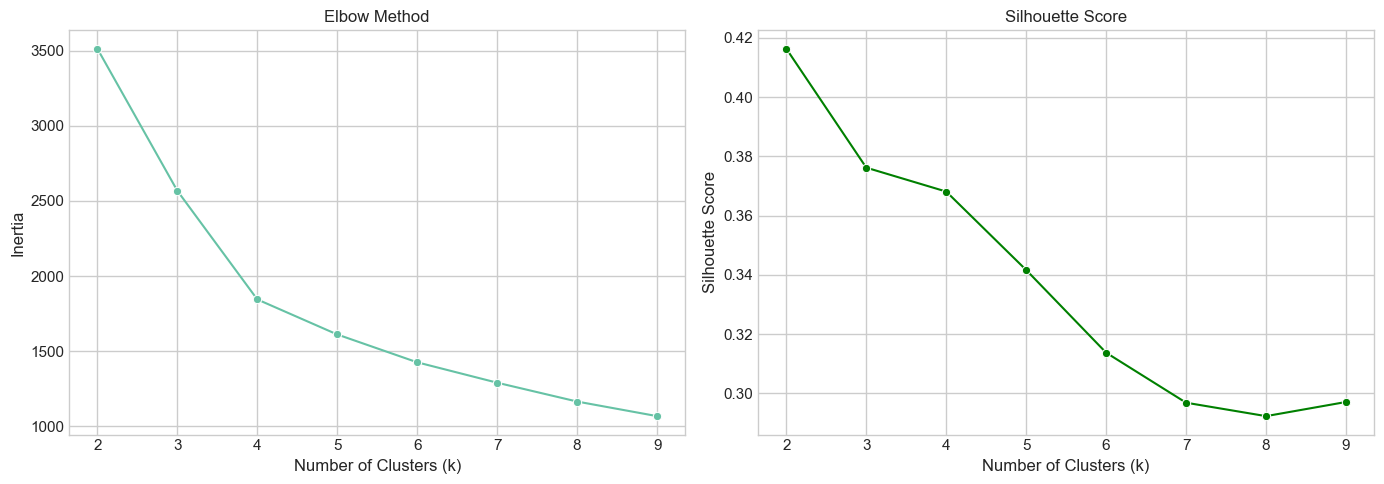

In [97]:
# Visualizing the results

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
sns.lineplot(
    data=results_df,
    x="k",
    y="Inertia",
    marker="o",
    ax=axes[0]
)


axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

# Silhouette Plot
sns.lineplot(
    data=results_df,
    x="k",
    y="Silhouette",
    marker="o",
    color="green",
    ax=axes[1]
)

axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

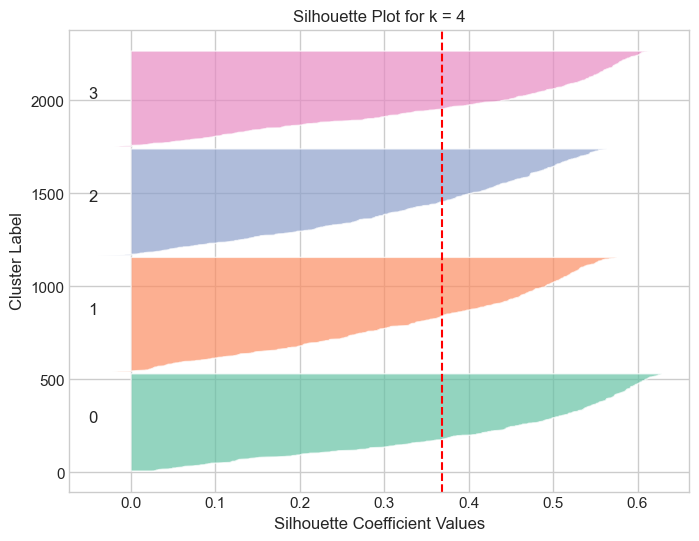

In [98]:
# Based on the visualization above choosing K=4

# Fitting model with choosen K

k = 4

pipeline.set_params(kmeans__n_clusters=k)
labels = pipeline.fit_predict(X)
data['Cluster'] = labels

X_transformed = pipeline.named_steps["preprocessing"].transform(X)

# Compute Silhouette Values Per Sample
sample_silhouette_values = silhouette_samples(X_transformed, labels)

# Create Silhouette Plot with Seaborn

plt.figure(figsize=(8,6))

y_lower = 10

for i in range(k):
    
    cluster_silhouette_vals = sample_silhouette_values[labels == i]
    cluster_silhouette_vals.sort()
    
    size_cluster = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster
    
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette_vals,
        alpha=0.7
    )
    
    plt.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
    
    y_lower = y_upper + 10

plt.axvline(np.mean(sample_silhouette_values), color="red", linestyle="--")

plt.title(f"Silhouette Plot for k = {k}")
plt.xlabel("Silhouette Coefficient Values")
plt.ylabel("Cluster Label")

plt.show()

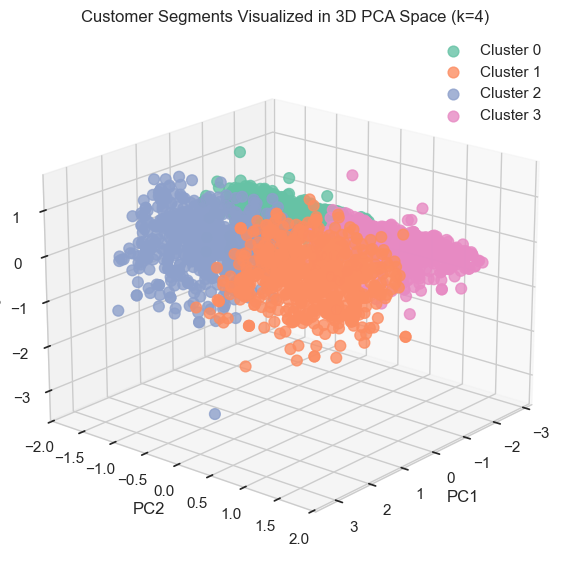

In [99]:
# Visualizing clusters using PCA - 3D

from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_transformed)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for cluster in np.unique(labels):
    cluster_data = X_pca3[labels == cluster]
    ax.scatter(
        cluster_data[:, 0],
        cluster_data[:, 1],
        cluster_data[:, 2],
        label=f'Cluster {cluster}',
        s=60,
        alpha=0.8
    )

ax.set_xlabel("PC1") # Total_Spending
ax.set_ylabel("PC2") # Recency
ax.set_zlabel("PC3") # Total_Purchases
ax.legend()
ax.view_init(elev=20, azim=40)
plt.title(f"Customer Segments Visualized in 3D PCA Space (k={k})")
plt.show()

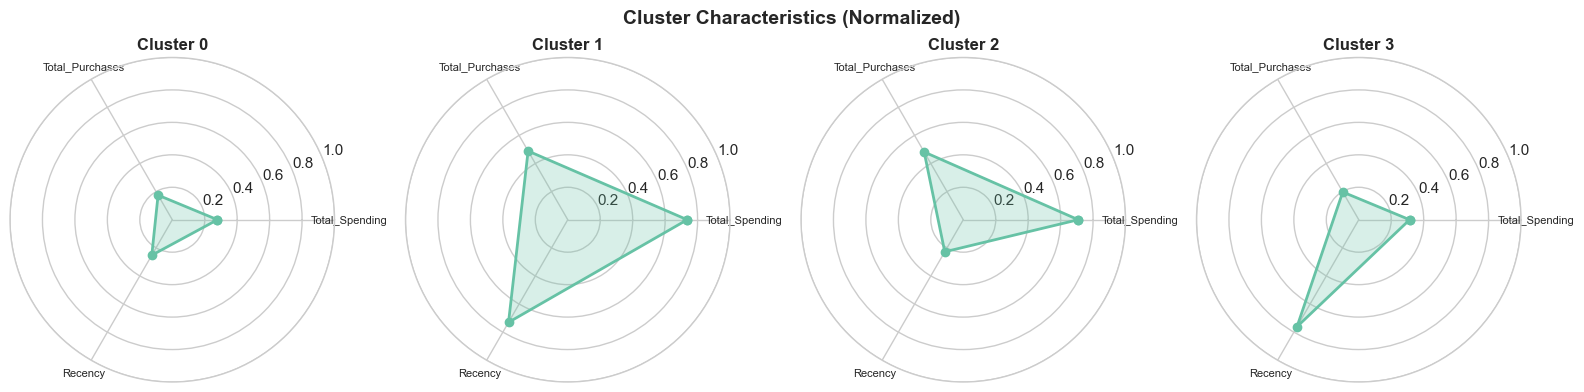

In [100]:
# Create a radar chart for cluster comparison (normalized)
from sklearn.preprocessing import MinMaxScaler

# Select features for radar
radar_features = ['Total_Spending', 'Total_Purchases', 'Recency']

# Normalize for radar chart
scaler_radar = MinMaxScaler()
radar_data = scaler_radar.fit_transform(data[radar_features])
radar_df = pd.DataFrame(radar_data, columns=radar_features)
radar_df['Cluster'] = data['Cluster'].values

# Plot radar
fig, axes = plt.subplots(1, 4, figsize=(16, 4), subplot_kw=dict(projection='polar'))

for i, cluster in enumerate(range(4)):
    cluster_means = radar_df[radar_df['Cluster'] == cluster][radar_features].mean().values
    
    # Repeat first value to close the radar
    values = np.concatenate((cluster_means, [cluster_means[0]]))
    angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
    angles += angles[:1]
    
    axes[i].plot(angles, values, 'o-', linewidth=2)
    axes[i].fill(angles, values, alpha=0.25)
    axes[i].set_xticks(angles[:-1])
    axes[i].set_xticklabels(radar_features, size=8)
    axes[i].set_title(f'Cluster {cluster}', fontweight='bold' )
    axes[i].set_ylim(0, 1)

plt.suptitle('Cluster Characteristics (Normalized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

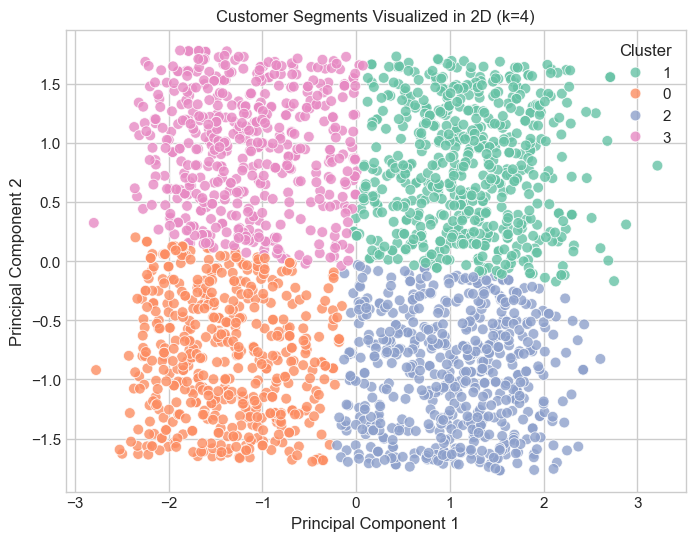

Explained variance ratio: [0.59789838 0.33316074]
Total explained variance: 0.9310591179532466


In [101]:
# Visualizing clusters using PCA - 2D

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_transformed)
plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": labels.astype(str)
})
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=60,
    alpha=0.8
)

plt.title(f"Customer Segments Visualized in 2D (k={k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

In [102]:
# RFM Cluster Summary
rfm_summary = data.groupby('Cluster')[['Recency', 'Total_Purchases', 'Total_Spending']] \
                  .agg(['mean', 'median']).round(2)

# Add cluster size
cluster_sizes = data['Cluster'].value_counts().sort_index()
rfm_summary[('Cluster_Size', '')] = cluster_sizes.values

rfm_summary

Recency        Total_Purchases        Total_Spending         \
           mean median            mean median           mean median   
Cluster                                                               
0         25.01   25.0            7.52    7.0          11.39  11.37   
1         72.28   72.0           21.02   21.0          25.54  26.21   
2         22.60   23.0           20.73   20.0          24.68  25.27   
3         75.34   76.0            8.48    8.0          12.47  12.47   

        Cluster_Size  
                      
Cluster               
0                524  
1                616  
2                573  
3                516

Recency : 
Clusters 0 and 2 have low recency which means recent purchases
Clusters 1 and 3 have high recency which means customers have not bought since long

Total_Purchases :
Clusters 1 & 2 are frequent buyers
Clusters 0 and 3 are not buying frequently

Total Spending:
Clusters 1 & 2 are valuable customers
Clusters 0 and 3 are not spending much

Cluster 0 : Low recency, Low fequency, low monetory : Recent (new) customers
Reccomendation can be : Engagement campaigns: encourage more purchases by giving incentives for 2nd purchases, small bundle offers, cross-sell

Cluster 1 : High Recency, High Frequency, High Monetory : Potential Loyal cause they have not purchased recently
Recommendation can be : Re-engagement campaigns: email, loyalty points, personalized offers,Win-back campaigns,Personalized emails, “We miss you” offers, Exclusive comeback discounts

Cluster 2 : Low recency, High Frequency, High Monetory :  Loyal Customers
Recommendation can be : Reward and retain: VIP offers, early access, premium campaigns

Cluster 3 : High Recency, Low Frequency, Low Monetory : Low Value (At Risk) customers
Recommendation can be : Win-back campaigns: discounts, reminders, Low-cost reactivation campaigns,If inactive long enough then suppress from marketing, Don’t overspend on acquisition/retention here




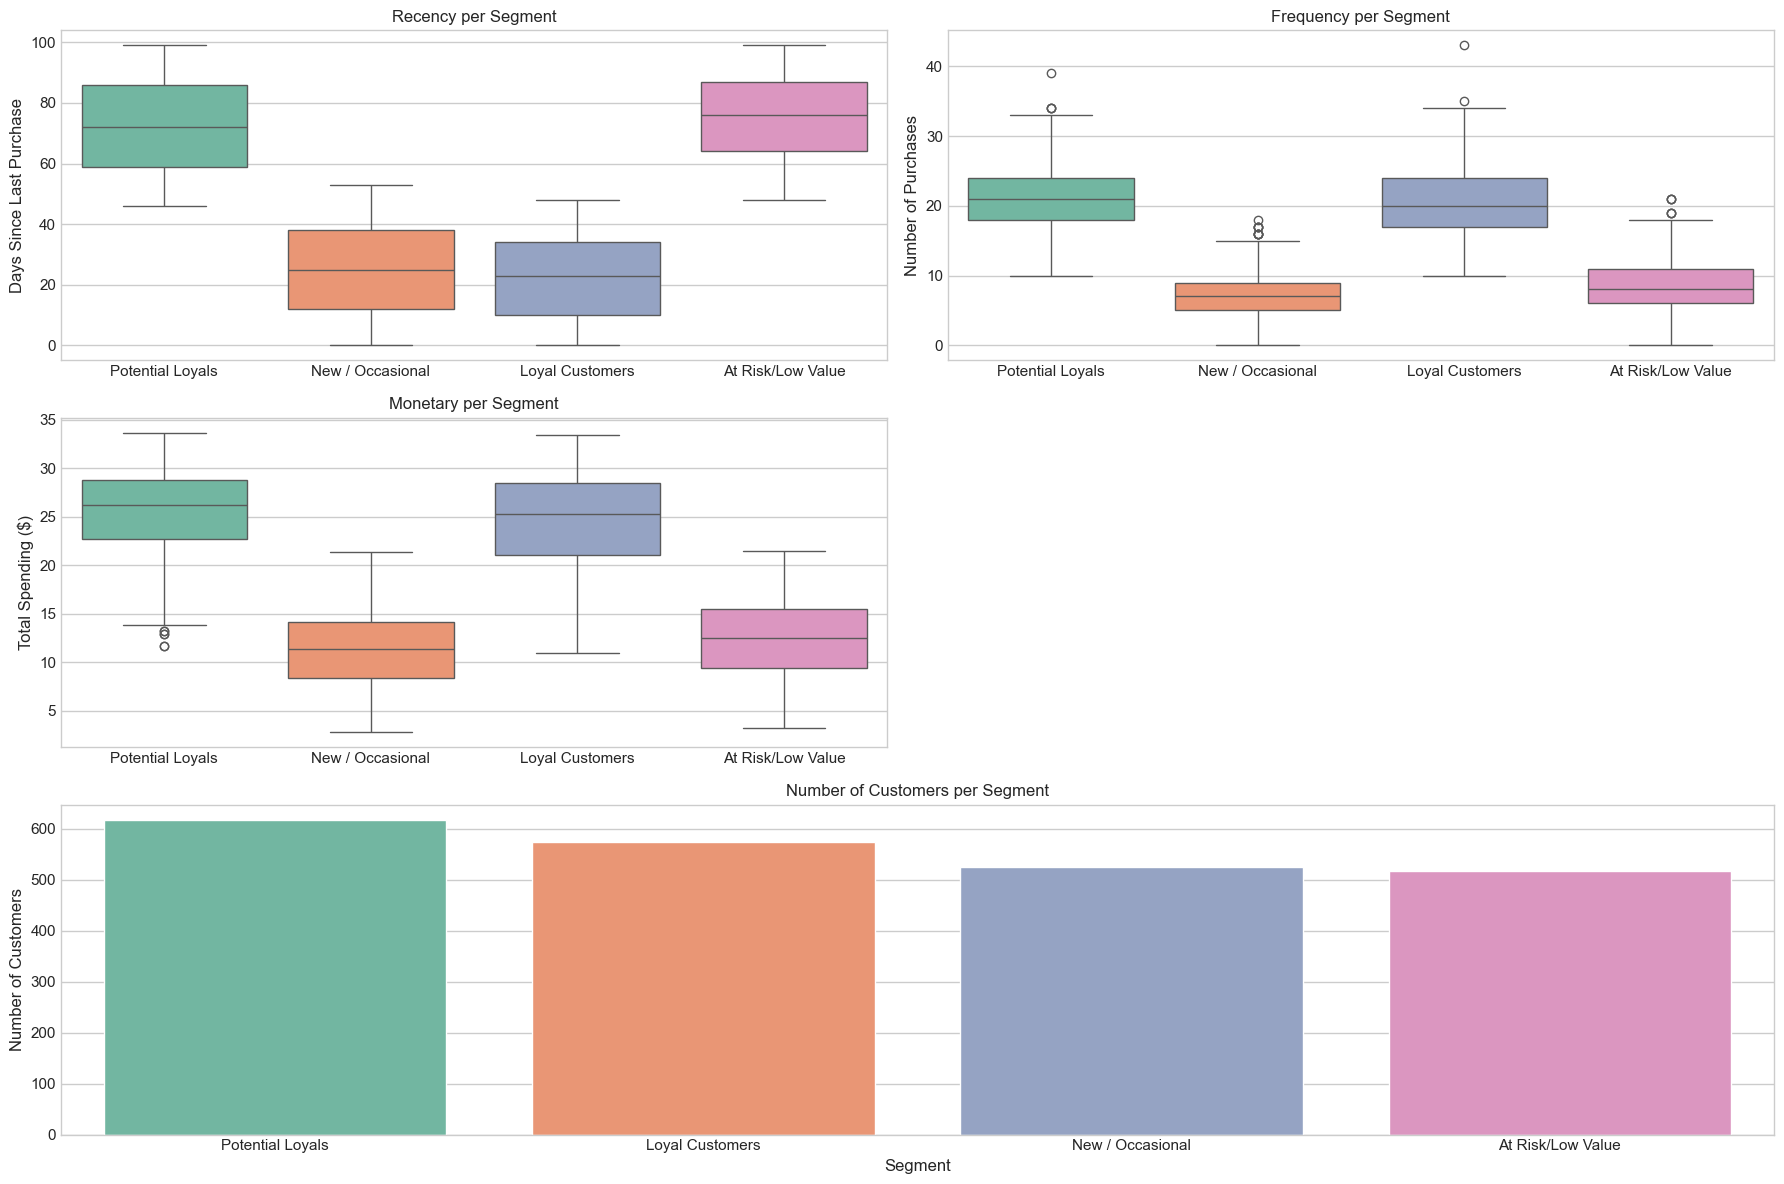

In [103]:
# Your k=4 clusters and suggested segments
cluster_names = {
    0: "New / Occasional",
    1: "Potential Loyals",
    2: "Loyal Customers",
    3: "At Risk/Low Value"
}

data['Segment'] = data['Cluster'].map(cluster_names)

# Compute cluster sizes
cluster_sizes = data['Segment'].value_counts()

# Create figure
fig = plt.figure(figsize=(18, 12))


# 1. Boxplot: Recency

ax1 = plt.subplot2grid((3, 2), (0, 0))
sns.boxplot(
    x='Segment', 
    y='Recency', 
    data=data, 
    hue='Segment',  
    palette='Set2', 
    dodge=False, 
    ax=ax1
)

ax1.set_title('Recency per Segment')
ax1.set_xlabel('')
ax1.set_ylabel('Days Since Last Purchase')


# 2. Boxplot: Frequency (Total_Purchases)

ax2 = plt.subplot2grid((3, 2), (0, 1))
sns.boxplot(
    x='Segment', 
    y='Total_Purchases', 
    data=data, 
    hue='Segment', 
    palette='Set2', 
    dodge=False, 
    ax=ax2
)

ax2.set_title('Frequency per Segment')
ax2.set_xlabel('')
ax2.set_ylabel('Number of Purchases')


# 3. Boxplot: Monetary (Total_Spending)

ax3 = plt.subplot2grid((3, 2), (1, 0))
sns.boxplot(
    x='Segment', 
    y='Total_Spending', 
    data=data, 
    hue='Segment', 
    palette='Set2', 
    dodge=False, 
    ax=ax3
)

ax3.set_title('Monetary per Segment')
ax3.set_xlabel('')
ax3.set_ylabel('Total Spending ($)')



# 4. Cluster Sizes
ax4 = plt.subplot2grid((3, 2), (2, 0), colspan=2)
sns.barplot(
    x=cluster_sizes.index,
    y=cluster_sizes.values,
    hue=cluster_sizes.index,  # assign hue to satisfy seaborn v0.14
    palette='Set2',
    dodge=False,
    ax=ax4
)

ax4.set_title('Number of Customers per Segment')
ax4.set_xlabel('Segment')
ax4.set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [104]:
# Revenue Contribution per Segment - Who drives revenue, Whether revenue is concentrated, 
#                                                        Segment-level productivity

# Aggregate revenue metrics
segment_revenue = (
    data.groupby('Segment')
      .agg(
          Customers=('ID', 'count'),
          Total_Revenue=('Total_Spending', 'sum'),
          Avg_Revenue_per_Customer=('Total_Spending', 'mean'),
          Avg_Purchases=('Total_Purchases', 'mean')
      )
      .reset_index()
)

# Total revenue across all segments
total_revenue = segment_revenue['Total_Revenue'].sum()

# Revenue share %
segment_revenue['Revenue_Share_%'] = (
    segment_revenue['Total_Revenue'] / total_revenue * 100
)

segment_revenue.sort_values('Total_Revenue', ascending=False)


,Segment,Customers,Total_Revenue,Avg_Revenue_per_Customer,Avg_Purchases,Revenue_Share_%
3,Potential Loyals,616,15730.641844,25.536756,21.021104,37.212538
1,Loyal Customers,573,14142.042267,24.680702,20.727749,33.454533
0,At Risk/Low Value,516,6432.098454,12.465307,8.482558,15.215826
2,New / Occasional,524,5967.641575,11.388629,7.519084,14.117103


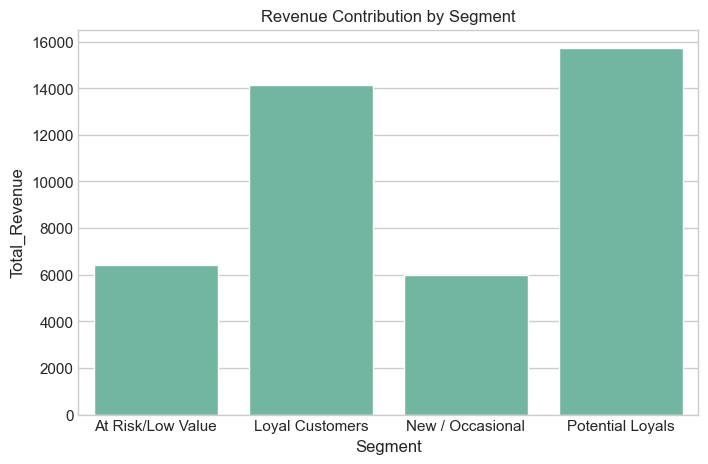

In [105]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_revenue,
    x='Segment',
    y='Total_Revenue'
)

plt.title("Revenue Contribution by Segment")
plt.show()

In [106]:
# Revenue at Risk

at_risk_segment = "At Risk/Low Value"  

revenue_at_risk = segment_revenue.loc[
    segment_revenue['Segment'] == at_risk_segment,
    'Total_Revenue'
].values[0]

revenue_at_risk_pct = revenue_at_risk / total_revenue * 100

print("Revenue at Risk:", revenue_at_risk)
print("Revenue at Risk %:", revenue_at_risk_pct)

Revenue at Risk: 6432.098454225702
Revenue at Risk %: 15.215825884390915


In [107]:
# Growth simulation

low_segment = "At Risk/Low Value"  
high_segment = "Loyal Customers"  

low = segment_revenue[segment_revenue['Segment'] == low_segment]
high = segment_revenue[segment_revenue['Segment'] == high_segment]

size_low = low['Customers'].values[0]
avg_low = low['Avg_Revenue_per_Customer'].values[0]
avg_high = high['Avg_Revenue_per_Customer'].values[0]

uplift_rate = 0.20  # 20%

incremental_revenue = (
    uplift_rate * size_low * (avg_high - avg_low)
)

print("Potential Incremental Revenue:", incremental_revenue)

Potential Incremental Revenue: 1260.628759372269


In [108]:
# Growth simulation

# Define segments and marketing budget
segments = segment_revenue['Segment'].unique()  # All RFM segments
marketing_cost = 500  # Example marketing cost per segment
uplift_rates = [0.10, 0.20, 0.30, 0.50]  # 10%, 20%, 30%, 50%

# Store results
all_results = []

for segment in segments:
    # Skip Loyal Customers if desired, since conversion from Loyal to Loyal doesn't make sense
    if segment == "Loyal Customers":
        continue

    # Segment data
    low = segment_revenue[segment_revenue['Segment'] == segment]
    high = segment_revenue[segment_revenue['Segment'] == "Loyal Customers"]

    size_low = low['Customers'].values[0]
    avg_low = low['Avg_Revenue_per_Customer'].values[0]
    avg_high = high['Avg_Revenue_per_Customer'].values[0]

    # Calculate for different uplift rates
    for rate in uplift_rates:
        incremental_revenue = rate * size_low * (avg_high - avg_low)
        roi = (incremental_revenue - marketing_cost) / marketing_cost * 100
        all_results.append({
            'Segment': segment,
            'Uplift Rate (%)': rate*100,
            'Incremental Revenue ($)': round(incremental_revenue, 2),
            'Marketing Cost ($)': marketing_cost,
            'ROI (%)': round(roi, 2)
        })

# Convert to DataFrame for visualization
results_df = pd.DataFrame(all_results)
results_df

,Segment,Uplift Rate (%),Incremental Revenue ($),Marketing Cost ($),ROI (%)
0,At Risk/Low Value,10.0,630.31,500,26.06
1,At Risk/Low Value,20.0,1260.63,500,152.13
2,At Risk/Low Value,30.0,1890.94,500,278.19
3,At Risk/Low Value,50.0,3151.57,500,530.31
4,New / Occasional,10.0,696.50,500,39.30
5,New / Occasional,20.0,1393.01,500,178.60
6,New / Occasional,30.0,2089.51,500,317.90
7,New / Occasional,50.0,3482.52,500,596.50
8,Potential Loyals,10.0,-52.73,500,-110.55
9,Potential Loyals,20.0,-105.47,500,-121.09


Converting 20% of At Risk Segment to Loyal Customers behavior adds $1260 revenue and 152% of ROI


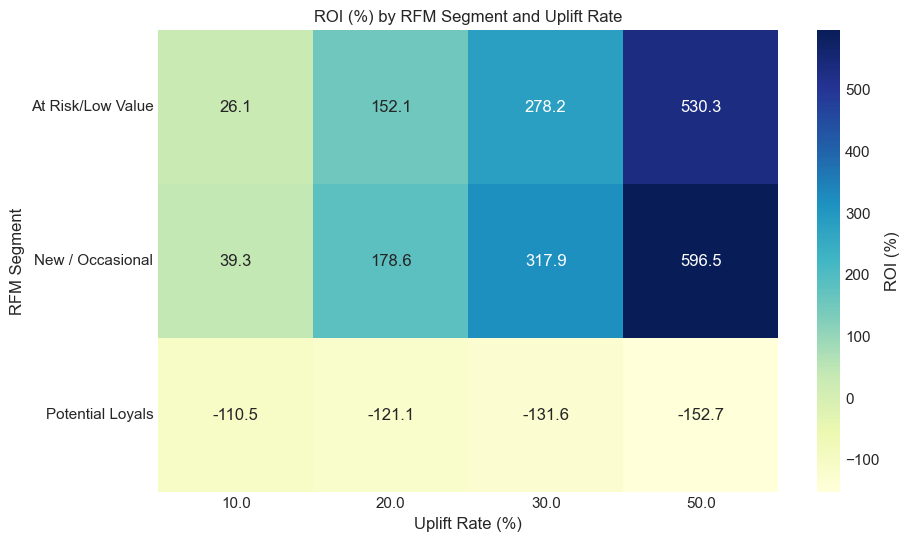

In [109]:

# Creating heatmap of the above table results

# Pivot the results to create a heatmap-friendly format
heatmap_df = results_df.pivot(
    index='Segment', 
    columns='Uplift Rate (%)', 
    values='ROI (%)'
)

plt.figure(figsize=(10,6))
sns.heatmap(
    heatmap_df, 
    annot=True, 
    fmt=".1f", 
    cmap="YlGnBu", 
    cbar_kws={'label': 'ROI (%)'}
)
plt.title("ROI (%) by RFM Segment and Uplift Rate")
plt.ylabel("RFM Segment")
plt.xlabel("Uplift Rate (%)")
plt.yticks(rotation=0)
plt.show()